# Neural network classifier

___

## Data onboarding and preprocessing

### Load data

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

dir_path = "training_data"

data = []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        data.append((label, pd.read_csv(file_path, header=None)))

### Apply PCA

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

weighted = False

data_PCA = []
for label, df in data: 

    # Convert data to a matrix
    coordinates = df.to_numpy()
    
    # Apply weights (helps retain up and down directions in the data)
    if weighted: 
        w = np.array([1.0, 2.0, 0.5])
        coordinates = coordinates * w

    # Fit PCA
    #coordinates_pca = coordinates[:, [1, 0, 2]]
    coordinates_pca = PCA(n_components=3).fit_transform(coordinates) 

    # Apply inverse weights
    if weighted: 
        coordinates_pca /= (-np.array(np.sort(-w)))

    # Scale the data to range [0, 1] (min-max-scaling)
    #X_pca_scaled = StandardScaler().fit_transform(X_pca)
    #X_pca_scaled = (X_pca- np.min(X_pca, axis=0))/ (np.max(X_pca) - np.min(X_pca))
    #X_pca_scaled = X_pca - np.mean(X_pca, axis=0) # Center the data 
    data_PCA.append((label, coordinates_pca))

### Convert data to images

20


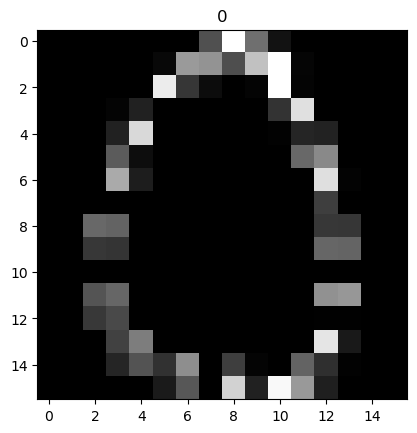

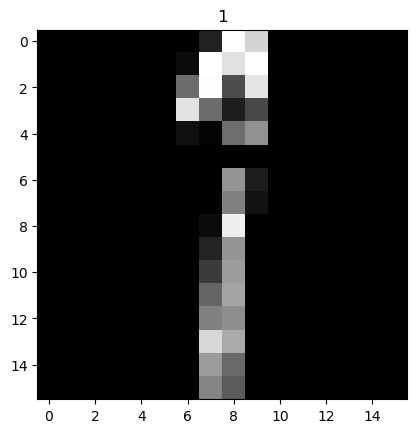

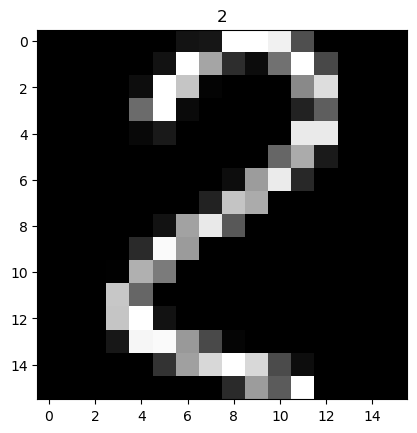

In [3]:
num_samples = sum([len(data_PCA[i]) for i in range(10)])
print(num_samples)

N = 16 # This is image width/height (square "images")
data_images = []

for label, coordinates in data_PCA: 

    # Scale the coordinates
    coordinates = coordinates - (np.min(coordinates, axis=0) + np.max(coordinates, axis=0)) / 2 # Center the sample to 0
    coordinates = coordinates / np.max(np.abs(coordinates)) # Scale to range [-1, 1]
    coordinates = coordinates * ((N-1) / 2) + ((N-1) / 2) # Scale to range [0, N-1]

    # Extract coordinates
    x, y, z = coordinates[:, 1], coordinates[:, 0], 1
    x_floor, x_ceil = np.floor(x).astype(int), np.ceil(x).astype(int)
    y_floor, y_ceil = np.floor(y).astype(int), np.ceil(y).astype(int)

    # Convert x, y data to pixels in an image
    image = np.zeros((N, N))
    image[y_floor, x_floor] += z * ((1 - y % 1) * (1 - x % 1))
    image[y_ceil, x_ceil] += z * ((y % 1) * (x % 1))
    image[y_floor, x_ceil] += z * ((x % 1) * (1 - y % 1))
    image[y_ceil, x_floor] += z * ((1 - x % 1) * (y % 1))

    # "Amplify" the signal 
    # image = 2 * image # Amplify

    # Clip the pixel values to range [0, 1]
    image = np.clip(image, 0, 1)
    
    # Flip the image (so that it is not upside down) and add it to list
    image = np.flip(image, 0)

    # Add image to list
    data_images.append((label, image))

# Show some images
for label, image in data_images[:300:100]: 
    plt.figure()
    plt.imshow(image, cmap='Grays_r')
    plt.title(label)


### Stack images and labels to arrays

In [4]:
X = np.stack([image for _, image in data_images])
y = np.array([label for label, _ in data_images])

___

## Training the model 

### Split data to training and test sets

In [5]:
from neural_network import *
from sklearn.model_selection import train_test_split

# Flatten the samples
X_flat = np.array([x.flatten() for x in X])

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Split the data to training/validation and test sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_encoded, test_size=0.15, stratify=y, random_state=42)

### Define model

In [6]:
from numpy.random import uniform

model = NeuralNetworkClassifier(
    Dense(uniform(-0.1, 0.1, size=(X_flat.shape[1], 256)), np.zeros(256), ReLU),
    Dense(uniform(-0.1, 0.1, size=(256, 128)), np.zeros(128), ReLU), 
    Dense(uniform(-0.1, 0.1, size=(128, 10)), np.zeros(10), Softmax)
)

### Train the model 

  1%|          | 115/10000 [00:02<03:40, 44.88it/s]


Model accuracy (training set): 97 %
Model accuracy (test set): 92 %


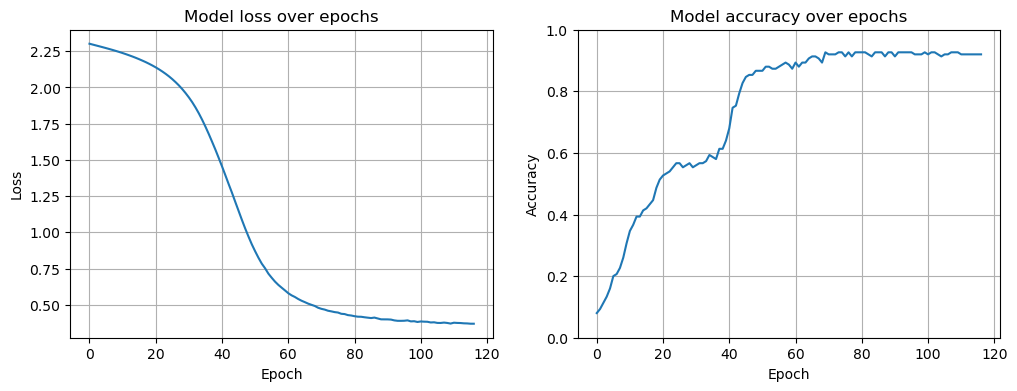

In [7]:
import matplotlib.pyplot as plt

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.1, 1e-4, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

Further training

  0%|          | 5/10000 [00:00<03:28, 48.03it/s]


Model accuracy (training set): 97 %
Model accuracy (test set): 92 %


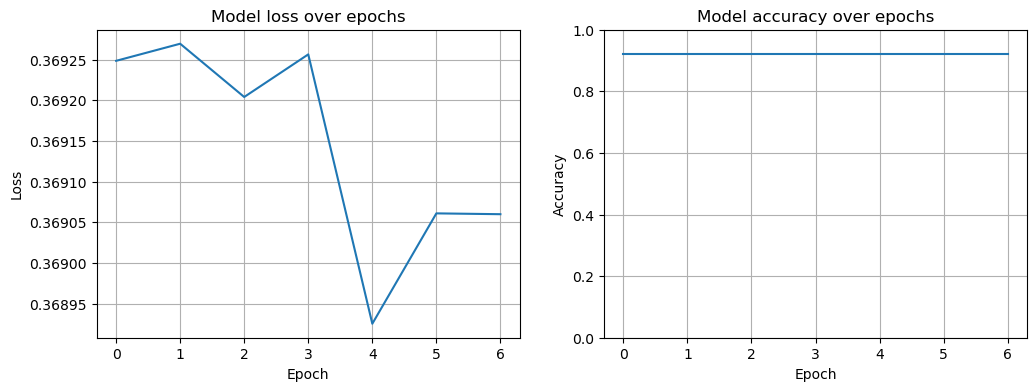

In [8]:
# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.01, 1e-5, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")